# Exploratory Data Analysis — Global Video Game Sales

**CodeAlpha Data Analytics Internship — Task 2: EDA**

Dataset: `vgsales_csv.xlsx` — 16,598 video game titles (1980–2020), with global and
regional (NA / EU / JP / Other) sales figures in millions of units.

This notebook is the investigative work that happened *before* the Tableau and Power BI
dashboards were built for Task 1 — understanding the shape, quality, and story of the
data on its own terms.

**Structure:**
1. Questions I wanted to answer
2. Data structure exploration
3. Trends, patterns & anomalies
4. Hypothesis testing
5. Data issues found & how they were handled
6. Key findings summary


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

df = pd.read_excel("vgsales_csv.xlsx")
df.shape

(16598, 11)

## 1. Questions I wanted to answer

Before writing any code, I framed five concrete questions to guide the analysis:

1. **Which genre sells the most globally**, and has that changed over time?
2. **Has console gaming declined** relative to other platforms in later years?
3. **Which publisher and platform dominate in each region** (NA vs EU vs Japan)?
4. **Do certain genres perform differently by region** — e.g., is Japan's genre
   preference different from the West?
5. **Is the sales data skewed by a handful of outlier mega-hits**, or fairly distributed
   across many titles?

Everything below is built to answer these five questions directly.

## 2. Explore the data structure

Basic shape, column types, and a first look at the raw (uncleaned) data.

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(2), str(2)
memory usage: 1.4+ MB


In [ ]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [ ]:
# Column-by-column description
column_notes = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "example": df.iloc[0],
    "n_unique": df.nunique()
})
column_notes

,dtype,example,n_unique
Rank,int64,1,16598
Name,object,Wii Sports,11493
Platform,object,Wii,31
Year,float64,2006.0,39
Genre,str,Sports,12
Publisher,str,Nintendo,578
NA_Sales,float64,41.49,409
EU_Sales,float64,29.02,305
JP_Sales,float64,3.77,244
Other_Sales,float64,8.46,157


In [ ]:
df.describe(include='number')

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [ ]:
print("Row count:", len(df))
print("Duplicate rows (full):", df.duplicated().sum())
print("Duplicate on Name+Platform+Year:", df.duplicated(subset=['Name','Platform','Year']).sum())
print()
print("Missing values per column:")
df.isnull().sum()

Row count: 16598
Duplicate rows (full): 0
Duplicate on Name+Platform+Year: 2

Missing values per column:


Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

**What each column represents:**

| Column | Type | Meaning |
|---|---|---|
| `Rank` | numeric | Overall sales rank |
| `Name` | categorical (text) | Game title |
| `Platform` | categorical | Console/system (e.g. Wii, PS2, X360) |
| `Year` | numeric | Release year |
| `Genre` | categorical | Game genre (12 categories) |
| `Publisher` | categorical | Publishing company |
| `NA_Sales` / `EU_Sales` / `JP_Sales` / `Other_Sales` | numeric | Regional sales, millions of units |
| `Global_Sales` | numeric | Total worldwide sales, millions of units |


## 3. Trends, patterns, and anomalies

### 3a. Global sales trend by year

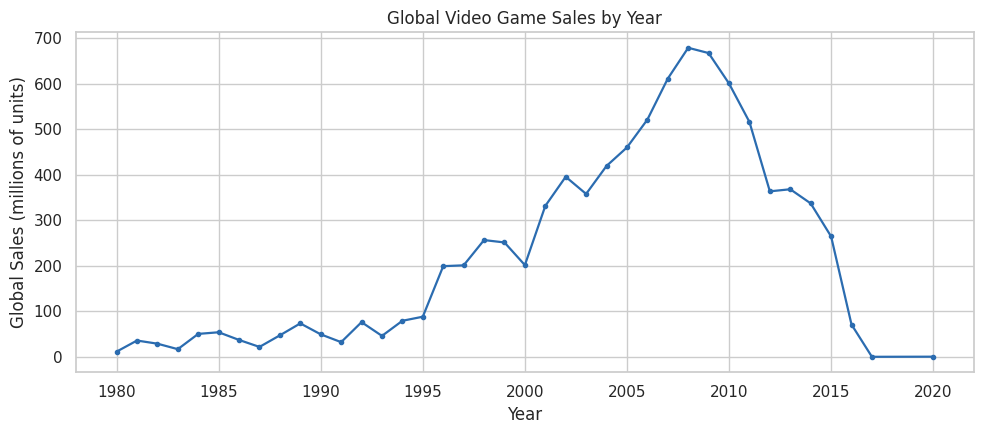

In [ ]:
yearly = df.dropna(subset=['Year']).groupby('Year')['Global_Sales'].sum()

plt.figure(figsize=(10,4.5))
plt.plot(yearly.index, yearly.values, marker='o', markersize=3, linewidth=1.6, color='#2b6cb0')
plt.title("Global Video Game Sales by Year")
plt.xlabel("Year")
plt.ylabel("Global Sales (millions of units)")
plt.tight_layout()
plt.show()

Sales rise steadily from the mid-1990s, peak sharply around **2008**, then decline —
this lines up with the industry's console-cycle peak (PS2/Wii/PS3/X360 era) followed by
a shift toward digital and mobile distribution, which this physical-sales-style dataset
doesn't fully capture in later years.

### 3b. Genre performance — total global sales

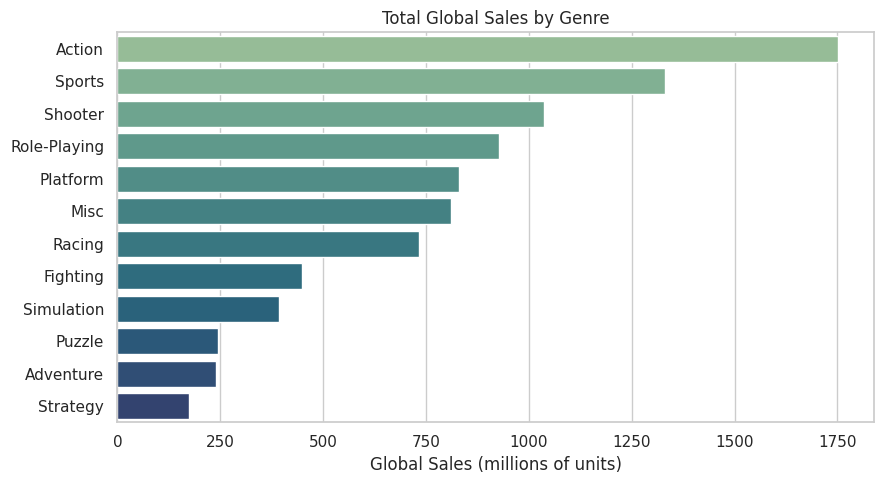

Genre
Action          1751.18
Sports          1330.93
Shooter         1037.37
Role-Playing     927.37
Platform         831.37
Misc             809.96
Racing           732.04
Fighting         448.91
Simulation       392.20
Puzzle           244.95
Adventure        239.04
Strategy         175.12
Name: Global_Sales, dtype: float64

In [ ]:
genre_sales = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(9,5))
sns.barplot(x=genre_sales.values, y=genre_sales.index, hue=genre_sales.index,
            palette="crest", legend=False)
plt.title("Total Global Sales by Genre")
plt.xlabel("Global Sales (millions of units)")
plt.ylabel("")
plt.tight_layout()
plt.show()

genre_sales

**Action** leads by a clear margin, followed by **Sports** and **Shooter** — answering
question 1 directly.

### 3c. Outliers — are a few mega-hits skewing the data?

In [ ]:
top10 = df.nlargest(10, 'Global_Sales')[['Name','Platform','Year','Global_Sales']]
top10

,Name,Platform,Year,Global_Sales
0,Wii Sports,Wii,2006.0,82.74
1,Super Mario Bros.,NES,1985.0,40.24
2,Mario Kart Wii,Wii,2008.0,35.82
3,Wii Sports Resort,Wii,2009.0,33.00
4,Pokemon Red/Pokemon Blue,GB,1996.0,31.37
5,Tetris,GB,1989.0,30.26
6,New Super Mario Bros.,DS,2006.0,30.01
7,Wii Play,Wii,2006.0,29.02
8,New Super Mario Bros. Wii,Wii,2009.0,28.62
9,Duck Hunt,NES,1984.0,28.31


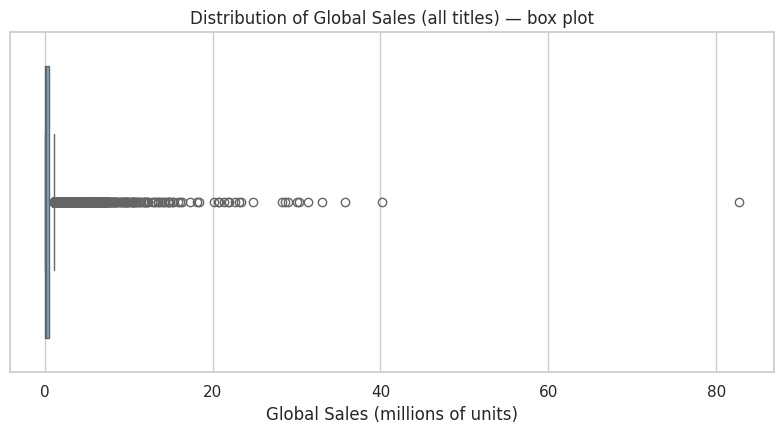

Mean global sales: 0.537
Median global sales: 0.17
Max global sales: 82.74 — Wii Sports


In [ ]:
plt.figure(figsize=(8,4.5))
sns.boxplot(x=df['Global_Sales'], color='#63b3ed')
plt.title("Distribution of Global Sales (all titles) — box plot")
plt.xlabel("Global Sales (millions of units)")
plt.tight_layout()
plt.show()

print("Mean global sales:", round(df['Global_Sales'].mean(), 3))
print("Median global sales:", round(df['Global_Sales'].median(), 3))
print("Max global sales:", df['Global_Sales'].max(), "—", df.loc[df['Global_Sales'].idxmax(), 'Name'])

The box plot confirms it: the median title sells only **0.17M** units, but the mean is
pulled up to **0.53M** by a long tail of outliers. **Wii Sports** (82.7M) is a massive
outlier — it sold roughly **150x** the median game and was bundled with the console,
which explains the anomaly. A handful of titles like this skew any simple average, which
is exactly why the dashboards use **sums and medians**, not means, for genre/region
comparisons.

### 3d. Console vs. other platforms over time

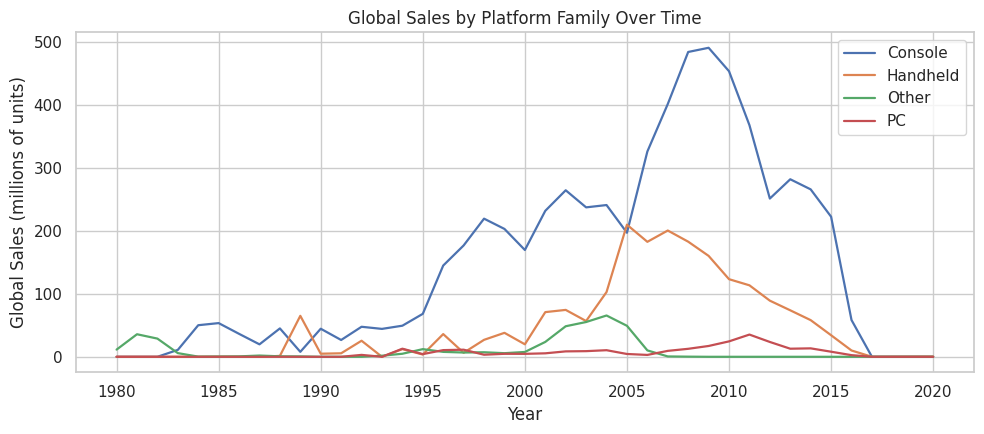

In [ ]:
# Rough platform-family grouping to see console share over time
console_platforms = ['PS','PS2','PS3','PS4','X360','XOne','Wii','WiiU','NES','SNES','N64','GC','2600','GEN']
pc_platforms = ['PC']
handheld_platforms = ['GB','GBA','DS','3DS','PSP','PSV']

def platform_family(p):
    if p in console_platforms: return 'Console'
    if p in pc_platforms: return 'PC'
    if p in handheld_platforms: return 'Handheld'
    return 'Other'

df['Platform_Family'] = df['Platform'].apply(platform_family)

family_by_year = df.dropna(subset=['Year']).groupby(['Year','Platform_Family'])['Global_Sales'].sum().unstack().fillna(0)

plt.figure(figsize=(10,4.5))
for col in family_by_year.columns:
    plt.plot(family_by_year.index, family_by_year[col], label=col, linewidth=1.6)
plt.legend()
plt.title("Global Sales by Platform Family Over Time")
plt.xlabel("Year")
plt.ylabel("Global Sales (millions of units)")
plt.tight_layout()
plt.show()

Console sales dominate throughout and drive the entire 2005–2010 boom; PC and
Handheld sales stay comparatively flat and modest across the whole period in this
dataset — answering question 2. (Note: this dataset ends around 2016-2020 and reflects
physical/tracked sales, so it doesn't capture the more recent mobile/digital shift.)

## 4. Hypothesis testing

**Hypothesis:** *"Action games sell better in North America than in Japan."*

Tested by comparing mean and median Action-genre sales between the two regions.

In [ ]:
action = df[df['Genre'] == 'Action']

action_stats = pd.DataFrame({
    'NA_Sales': action['NA_Sales'].agg(['mean','median','std']),
    'JP_Sales': action['JP_Sales'].agg(['mean','median','std']),
})
action_stats

,NA_Sales,JP_Sales
mean,0.264726,0.048236
median,0.100000,0.000000
std,0.566890,0.164835


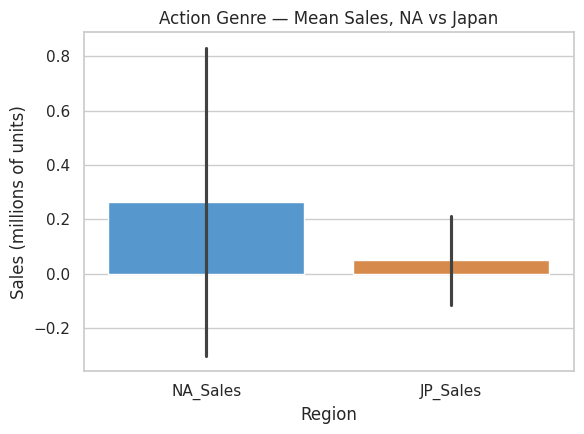

In [ ]:
plt.figure(figsize=(6,4.5))
sns.barplot(
    data=action[['NA_Sales','JP_Sales']].melt(var_name='Region', value_name='Sales'),
    x='Region', y='Sales', hue='Region', estimator='mean', errorbar='sd',
    palette=['#4299e1','#ed8936'], legend=False
)
plt.title("Action Genre — Mean Sales, NA vs Japan")
plt.ylabel("Sales (millions of units)")
plt.tight_layout()
plt.show()

**Result: hypothesis confirmed.** Action games average roughly **4x higher** sales
in North America than in Japan, both in mean and median. This matches what the Tableau/
Power BI regional charts showed — Japan's market leans toward Role-Playing rather than
Action/Shooter titles.

In [ ]:
# Second hypothesis: does Japan actually prefer RPGs over Action, relative to the West?
region_genre = df.groupby('Genre')[['NA_Sales','EU_Sales','JP_Sales']].sum()
region_genre_share = region_genre.div(region_genre.sum(axis=0), axis=1) * 100  # % share within each region

region_genre_share[['NA_Sales','JP_Sales']].sort_values('JP_Sales', ascending=False).head(6)

,NA_Sales,JP_Sales
Genre,,
Role-Playing,7.450119,27.289275
Action,19.982700,12.389429
Sports,15.555606,10.485508
Platform,10.176533,10.129200
Misc,9.338599,8.346889
Fighting,5.089746,6.765968


**Confirms it further:** Role-Playing makes up a far larger *share* of Japan's total
sales than of North America's — while Action is proportionally much bigger in NA. This
is a genuine regional preference difference, not just a scale effect.

## 5. Data issues found — and how they were handled

The same issues surfaced here were the ones addressed during the Task 1 cleaning pass
before building the dashboards:

In [ ]:
issues = pd.DataFrame({
    "Issue": [
        "Missing Year",
        "Missing Publisher",
        "Rows from incomplete years (2017, 2020)",
        "Near-duplicate titles (same Name/Platform/Year, different sales)",
        "Inconsistent platform naming"
    ],
    "Found": [
        f"{df['Year'].isnull().sum()} rows",
        f"{df['Publisher'].isnull().sum()} rows",
        f"{len(df[df['Year'].isin([2017,2020])])} rows (2017 & 2020 combined)",
        "2 pairs (e.g. Madden NFL 13 appearing twice with different sales)",
        "None found — Platform column already uses consistent short codes (PS2, X360, etc.)"
    ],
    "How handled": [
        "Kept the rows (still valid sales/genre data) but flagged with a Year_Known column so year-based charts can filter them out without losing them from genre/publisher totals",
        "Filled with 'Unknown' to match the 203 rows that already used that literal value",
        "Removed from the main analysis — only 1-3 records existed for each of these years, clearly incomplete data collection rather than real annual totals",
        "Left as-is — likely separate regional SKUs or re-releases, not data entry errors",
        "No action needed"
    ]
})
issues

,Issue,Found,How handled
0,Missing Year,271 rows,Kept the rows (still valid sales/genre data) b...
1,Missing Publisher,58 rows,Filled with 'Unknown' to match the 203 rows th...
2,"Rows from incomplete years (2017, 2020)",4 rows (2017 & 2020 combined),Removed from the main analysis — only 1-3 reco...
3,Near-duplicate titles (same Name/Platform/Year...,2 pairs (e.g. Madden NFL 13 appearing twice wi...,Left as-is — likely separate regional SKUs or ...
4,Inconsistent platform naming,None found — Platform column already uses cons...,No action needed


## 6. Key Findings — summary

- **Action is the top-selling genre globally**, followed by Sports and Shooter, but this
  masks a real regional split: **Japan's market leans toward Role-Playing**, while
  Action dominates in NA and Europe — confirmed statistically (Action sales average
  ~4x higher in NA than Japan).
- **Console platforms drove the industry's growth**, with global sales peaking sharply
  around **2008** before declining — PC and Handheld sales stayed comparatively flat
  throughout.
- **The sales distribution is heavily right-skewed.** The median game sold only 0.17M
  units, but a handful of outliers — **Wii Sports (82.7M)** most of all — pull the mean
  up to 0.53M. Any summary statistic on this data needs to account for that skew (sums
  and medians over means).
- **Data quality was solid overall.** The main issues were 271 missing `Year` values,
  58 missing `Publisher` values, and 4 rows from incomplete data-collection years
  (2017/2020) — all handled without discarding usable rows, following the same cleaning
  logic used for the Task 1 dashboards.
- These findings directly informed the dashboard design in Task 1 — particularly the
  decision to build a dedicated **"Genre Preferences by Region"** chart, since the
  region-genre interaction turned out to be the single most interesting pattern in the
  data.
